In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import glob #for path/to/folder
from collections import Counter

#for extracting hand landmarks
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

### What we know about the dataset
[Link to the Kaggle Set](https://www.kaggle.com/datasets/ayuraj/asl-dataset)
* A bunch of images of A-Z and 0-9 in ASL (we'll be focusing on A-Z except J and Z since they require more hand motions); 400x400 cropped jpeg images
* each character has many versions/images of the sign, with slight variations in each of the hand positions to account for different lighting
* as mentioned in the kaggle set's description, this is mainly tailored to CNNs, but we should be able to use this with other models (like Linear SVMs)


In [2]:
#reading data from asl dataset:
img_dir = 'asl_dataset'
sub_dirs = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y'] #only looking at these characters 
sub_dirs_count, indx = [], 0
data = [] 
for dir in sub_dirs:
    path = f'{img_dir}/{dir}'
    #print(path)
    data_path = os.path.join(f'{img_dir}/{dir}',"*.jpeg") # *.jpeg is to only read files of .jpeg
    files = glob.glob(data_path) 
    count_files = 0 #just to help find all the images of each letter in dataset
    for f1 in files: 
        img = cv2.imread(f1) 
        #make sure img is read and exists
        if img is None:
            print("failed to load ", f1)
            
        #change bgr to rgb
        RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        data.append(RGB_img) 
        count_files += 1
    sub_dirs_count.append((sub_dirs[indx], count_files))
    indx+=1
#print(len(data))
print("successfully read all images")
# just to make sure image is stored properly
#plt.imshow(data[0])
#plt.waitforbuttonpress()
#plt.close('all')

successfully read all images


# of Images in dataset: 1605


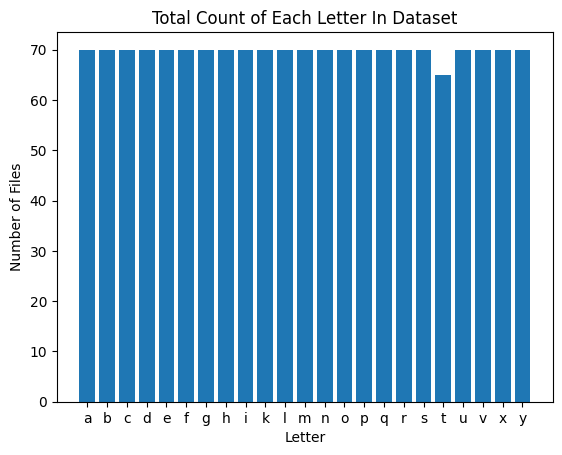

In [3]:
#information of all the images:
print("# of Images in dataset:", len(data))
#print(sub_dirs_count)
plt.bar(*zip(*sub_dirs_count))
plt.title("Total Count of Each Letter In Dataset")
plt.xlabel("Letter")
plt.ylabel("Number of Files")
plt.show()

Each letter has 70 images, except t, which has 65 images.

### Preprocessing Data
Using the cropped hand images, grab hand landmark data using Google's Mediapipe library

In [ ]:
#installing mediapipe - note that Python version 3.13+ doesn't support mediapipe for some reason
#!pip install -q mediapipe

#using a model that is ready-made to extract hand points from an image
#for windows: 
#!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task 

#for mac:
!curl -O https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

#getting the drawing utils
mp_drawing = mp.solutions.drawing_utils

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7635k  100 7635k    0     0  5448k      0  0:00:01  0:00:01 --:--:-- 5450k


In [6]:
#setting up the hand landmark detection model:
base_options = python.BaseOptions(
    model_asset_path='hand_landmarker.task', 
    delegate=python.BaseOptions.Delegate.CPU
    )
options = vision.HandLandmarkerOptions(
    base_options=base_options, 
    running_mode=vision.RunningMode.IMAGE, 
    num_hands=1, #dataset only shows 1 hand for each sign
    min_hand_detection_confidence=0.1,
    min_tracking_confidence=0.2
    )
detector = vision.HandLandmarker.create_from_options(options=options)


I0000 00:00:1776395894.149272 22394682 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1776395894.166750 22397012 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776395894.181720 22397012 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [7]:
#getting hand landmarks from one image:
#test = cv2.imread('asl_dataset/a/hand1_a_bot_seg_4_cropped.jpeg')
#test = cv2.cvtColor(test, cv2.COLOR_BGR2RGB)

test = cv2.resize(data[0], (640, 480))

test = np.ascontiguousarray(test)
image = mp.Image(
    image_format=mp.ImageFormat.SRGB, 
    data=test
    )

result = detector.detect(image)

W0000 00:00:1776395898.900609 22397005 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


In [8]:
print("hands detected = ", len(result.hand_landmarks))
print(result.hand_landmarks)

hands detected =  1
[[NormalizedLandmark(x=0.4141947329044342, y=0.8319546580314636, z=-1.9755117364184116e-07, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.6568422317504883, y=0.7393732070922852, z=-0.029190361499786377, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.7823507785797119, y=0.4882619082927704, z=-0.02083217352628708, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.7991763949394226, y=0.23070889711380005, z=-0.017086219042539597, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.7858151793479919, y=0.05441807955503464, z=-0.005858207121491432, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.670793890953064, y=0.3055427372455597, z=0.024315480142831802, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.6523514986038208, y=0.10176597535610199, z=-0.0375262089073658, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.6540089845657349, y=0.23360082507133484, z=-0.07832343131303787, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.658

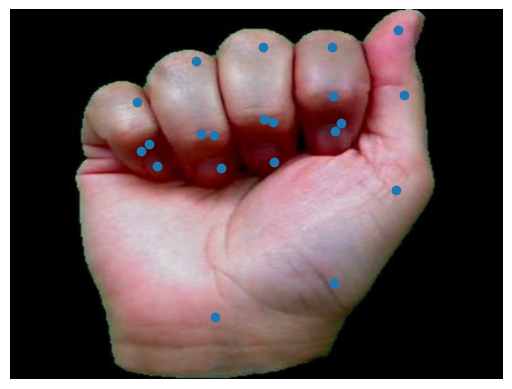

In [9]:
def plot_points(rgb_img, detection_result):
    h, w, _ = rgb_img.shape

    plt.imshow(rgb_img)

    for hand_landmarks in detection_result.hand_landmarks:
        #scaling back to the image's dimensions
        xs = [lm.x * w for lm in hand_landmarks]
        ys = [lm.y * h for lm in hand_landmarks]

        plt.scatter(xs, ys)

    plt.axis('off')
    plt.show()

plot_points(test, detection_result=result)

Above code was just to make sure we are properly getting hand landmarks from the images. Notice how we had to scale the image before running it through the detector. We are not sure why this happens, but it could be due to the nature of the image itself being too hard for the detection model to get landmarks. 

However, trying this with [Google's Mediapipe Hand Detection Demo](https://colab.research.google.com/github/googlesamples/mediapipe/blob/main/examples/hand_landmarker/python/hand_landmarker.ipynb) proved this wrong. Will need to fix this.

------------------------------------------------------------
Below is old code that doesn't work. **DO NOT RUN THE BELOW CODE BLOCK!!**

In [ ]:
#now to get the landmarks of each hand sign:
hand_landmark_data = []
hand_landmarks_label = []
curr_index = 0
print(len(data))
for i in range(len(data)):
    test = cv2.resize(data[i], (640, 480))

    test = np.ascontiguousarray(test)
    image = mp.Image(
        image_format=mp.ImageFormat.SRGB, 
        data=test
    )
    result = detector.detect(image) #gets all hand landmarks 
                                                   #in the image for each hand detected
    
    if not result.hand_landmarks:
        continue
    else:
        hand = result.hand_landmarks[0]
        coords = []
        for landmark in hand:
            coords.extend([landmark.x, landmark.y, landmark.z])

        hand_landmark_data.append(coords)
        label, label_index = curr_index//70, curr_index % 70
        if label == 22:
            print(label_index)
        if label == 19 and label_index >= 65: #there are only 65 images of t sign
            print(label_index)
            hand_landmarks_label.append('u')
        else:
            hand_landmarks_label.append(sub_dirs[label])

    curr_index+=1

print(len(hand_landmark_data))


------------------------------------------------------------

In [12]:
#storing dataset and labels:
hand_landmark_data = []
hand_landmark_label = []

#directories of dataset
img_dir = 'asl_dataset'
sub_dirs = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y'] #only looking at these characters 
for dir in sub_dirs:
    path = f'{img_dir}/{dir}'
    #print(path)
    data_path = os.path.join(f'{img_dir}/{dir}',"*.jpeg") # *.jpeg is to only read files of .jpeg
    files = glob.glob(data_path) 
    count_files = 0 #just to help find all the images of each letter in dataset
    for f1 in files: 
        img = cv2.imread(f1) 
        #make sure img is read and exists
        if img is None:
            print("failed to load ", f1)
            continue
            
        #change bgr to rgb
        RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        #turn into mediapipe image before extracting landmarks (if possible)
        test = cv2.resize(RGB_img, (640, 480))
        test = np.ascontiguousarray(test)
        image = mp.Image(
            image_format=mp.ImageFormat.SRGB, 
            data=test
        )
        result = detector.detect(image) #gets all hand landmarks 
                                        #in the image for each hand detected
        if not result.hand_landmarks:
            continue
        else:
            hand = result.hand_landmarks[0]
            coords = []
            for landmark in hand:
                coords.extend([landmark.x, landmark.y, landmark.z])
            hand_landmark_data.append(coords)
            hand_landmark_label.append(dir)


### Analysis of Data

Due to limitations within Mediapipe's hand detection, certain images cannot have their hand landmarks marked since they might not show a full wrist, which is used as an origin point to detect the other joints of the hand. The dataset we're using has closely cropped images, some including wrists and some not including them. 

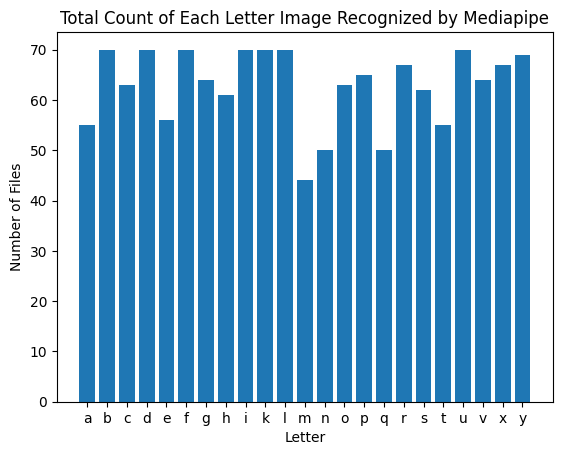

Counter({'b': 70, 'd': 70, 'f': 70, 'i': 70, 'k': 70, 'l': 70, 'u': 70, 'y': 69, 'r': 67, 'x': 67, 'p': 65, 'g': 64, 'v': 64, 'c': 63, 'o': 63, 's': 62, 'h': 61, 'e': 56, 'a': 55, 't': 55, 'n': 50, 'q': 50, 'm': 44})
Number of letters recoginzed by Mediapipe: 1445
Total images recognzied by Mediapipe: 90.03%


In [17]:
#get count of all hand images that were detected by the hand_landmarks.task model
label_counts = Counter(hand_landmark_label)

plt.bar(label_counts.keys(), label_counts.values())
plt.title("Total Count of Each Letter Image Recognized by Mediapipe")
plt.xlabel("Letter")
plt.ylabel("Number of Files")
plt.show()

print(label_counts)
print("Number of letters recoginzed by Mediapipe:", len(hand_landmark_data))

print("Total images recognzied by Mediapipe:", f"{len(hand_landmark_data)/len(data)*100:.2f}%")

The model seems to have detected landmarks for most of the dataset, with m having the least number of hands detected.